In [ ]:
import random
random.seed(1)

# Preparing data

No need to look at these steps

This block of code produces the following variables:

- X_train
- X_test
- y_train
- y_test

## Load and preprocess the data

No need to look at this data preprocessing as this is not assessed in this course (or involves old topics).

In [ ]:
from sklearn import linear_model
import seaborn as sns
import pandas as pd
# source: https://stackoverflow.com/questions/43798377/one-hot-encode-categorical-variables-and-scale-continuous-ones-simultaneouely
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Preprocess the data
dataset = sns.load_dataset('mpg')
#dataset.isna().sum()
dataset.drop('horsepower',axis=1) # this column contains missing values

# Define which columns should be encoded vs scaled
columns_to_encode = ['origin', 'name']
columns_to_scale  = ['mpg', 'cylinders', 'displacement',	'weight',	'acceleration',	'model_year']

# Instantiate encoder/scaler
scaler = StandardScaler()
ohe = OneHotEncoder(sparse_output=False,drop='first')

# Scale and Encode Separate Columns
scaled_columns  = scaler.fit_transform(dataset[columns_to_scale])
encoded_columns = ohe.fit_transform(dataset[columns_to_encode])

# Concatenate (Column-Bind) Processed Columns Back Together
processed_data = np.concatenate([scaled_columns, encoded_columns], axis=1)

processed_data.shape

(398, 312)

## Do test-train split

We have already covered this. See Lecture 5, and class exercise Lecture 7 - pytorch exercises answers.

In [ ]:
import math, random
def create_test_train_indicies(fraction_train, data_nrow):
  training_set_size = math.floor(fraction_train * data_nrow)
  train_indicies = random.sample(range(data_nrow), training_set_size)
  test_indicies = list(range(data_nrow))
  for i in train_indicies:
    test_indicies.remove(i)
  return train_indicies, test_indicies

In [ ]:
# create test-train splits
y = processed_data[:,1]
X = processed_data[:,2:]
nrow = X.shape[0]
fraction_train = 0.7 # 30-70 test-train split
train_indicies, test_indicies = create_test_train_indicies(fraction_train, nrow)
X_train = X[train_indicies,:]
X_test = X[test_indicies,:]
y_train = y[train_indicies]
y_test = y[test_indicies]

# Linear regression

In [ ]:
X_train.shape

(278, 310)

In [ ]:
def MSE(prediction_errors): # mean squared error
  return sum(prediction_errors ** 2)/len(prediction_errors)

In [ ]:
from sklearn.linear_model import LinearRegression
fitted_linear_regression_model = LinearRegression().fit(X_train, y_train)
train_error = MSE(fitted_linear_regression_model.predict(X_train) - y_train)
test_error = MSE(fitted_linear_regression_model.predict(X_test) - y_test)

In [ ]:
train_error

np.float64(0.007827062158389311)

In [ ]:
test_error

np.float64(0.2941770620607904)

In [ ]:
max(fitted_linear_regression_model.coef_)

np.float64(0.9902231299248287)

# LASSO

## Fit LASSO model different values of the tuning parameter



In [ ]:
alpha_list = [2**i for i in range(-17, 0)]
alpha_list

[7.62939453125e-06,
 1.52587890625e-05,
 3.0517578125e-05,
 6.103515625e-05,
 0.0001220703125,
 0.000244140625,
 0.00048828125,
 0.0009765625,
 0.001953125,
 0.00390625,
 0.0078125,
 0.015625,
 0.03125,
 0.0625,
 0.125,
 0.25,
 0.5]

In [ ]:
test_error_list = []
coef_list = []
best_test_error = np.inf
best_coef = np.nan
best_alpha = np.nan
for alpha in alpha_list:
  fitted_LASSO_model = linear_model.Lasso(alpha=alpha, max_iter=100000, tol=1e-5).fit(X_train, y_train)
  train_error = MSE(fitted_LASSO_model.predict(X_train) - y_train)
  test_error = MSE(fitted_LASSO_model.predict(X_test) - y_test)
  test_error_list.append(test_error)
  coef = fitted_LASSO_model.coef_.copy()
  coef_list.append(coef)
  if test_error < best_test_error:
    best_test_error = test_error
    best_alpha = alpha
    best_coef = coef

In [ ]:
print("best_alpha = ", best_alpha)
print("best_test_error = ", best_test_error)
print("number zero coefficients = ", sum(best_coef == 0.0))

best_alpha =  0.00390625
best_test_error =  0.08386757955002787
number zero coefficients =  303


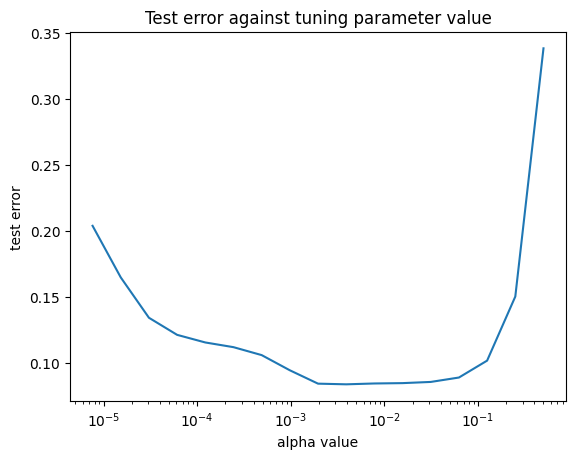

In [ ]:
import matplotlib.pyplot as plt
plt.plot(alpha_list, test_error_list)
plt.title('Test error against tuning parameter value')
plt.xscale("log")
plt.xlabel("alpha value")
plt.ylabel("test error")
plt.show()

## Inspect solution

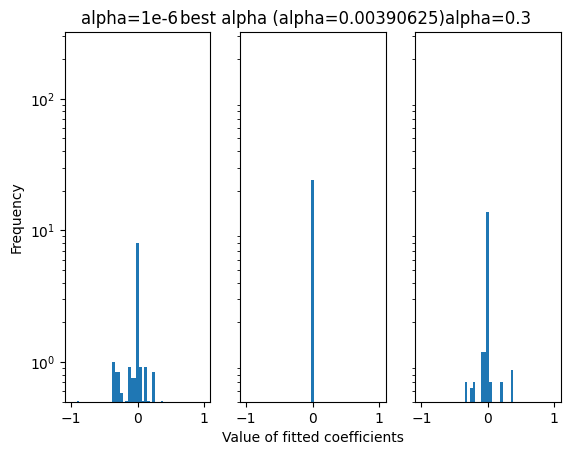

In [ ]:
import matplotlib.pyplot as plt
manual_bins = np.linspace(-1.0, 1.0, num=50)

plt.subplot(1, 3, 1)
plt.yscale('log')
plt.ylabel('Frequency')
n, bins, patches = plt.hist(x=coef_list[0], bins=manual_bins, density=True)
plt.title('alpha=1e-6   ')
plt.ylim((0.5,320))

plt.subplot(1, 3, 2)
plt.yscale('log')
n, bins, patches = plt.hist(x=best_coef, bins=manual_bins,  density=True)
plt.xlabel('Value of fitted coefficients')
plt.title('best alpha (alpha=' + str(best_alpha) + ')')
plt.tick_params(labelleft=False, left=False)
plt.ylim((0.5,320))

plt.subplot(1, 3, 3)
plt.yscale('log')
n, bins, patches = plt.hist(x=coef_list[6], bins=manual_bins,  density=True)
plt.title('alpha=0.3')
plt.ylim((0.5,320))
plt.tick_params(labelleft=False, left=False)

In [ ]:
sum(best_coef == 0.0)

np.int64(303)

# Elastic net

In lecture we considered:
$$
\min_{\beta} \frac{1}{n} \sum_{i=1}^n (y_i - X_i \cdot \beta)^2 + \alpha \| \beta \|_1 + \mu \| \beta \|_2^2
$$
where $\alpha, \mu \ge 0$ are tuning parameters.

However, python uses a different but equivilent formulation:
$$
\min_{\beta} \frac{1}{2 n} \sum_{i=1}^n (y_i - X_i \cdot \beta)^2 + \alpha \gamma \| \beta \|_1 + \frac{\alpha}{2} (1 - \gamma) \| \beta \|_2^2
$$
where $\alpha \ge 0$ and $0 \le \gamma \le 1$. Note they are equivlent because we can get the original parameters by setting:
$$
\alpha_{\text{original}} = 2 \alpha \gamma
$$
and
$$
\mu = \gamma \alpha
$$

In [ ]:
from sklearn.linear_model import ElasticNet
enet = ElasticNet(
    random_state=0,
    # both l1 ratio and alpha should be tuned
    alpha=0.001,
    l1_ratio=0.2 # l1_ratio = gamma
)
enet_fitted = enet.fit(X_train, y_train)

In [ ]:
test_error_enet = MSE(enet_fitted.predict(X_test) - y_test)
test_error_enet

np.float64(0.10214357846014009)

(0.0, 320.0)

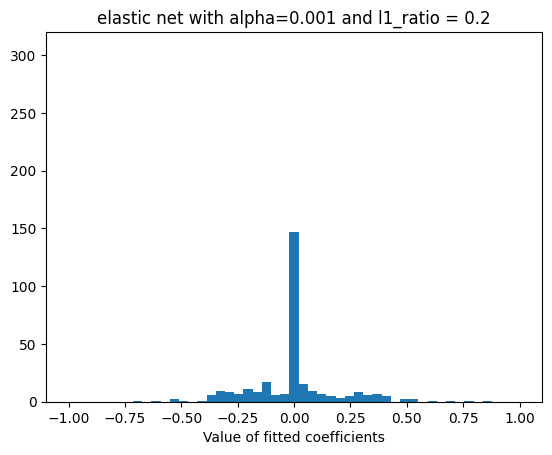

In [ ]:
n, bins, patches = plt.hist(x=enet_fitted.coef_, bins=manual_bins)
plt.xlabel('Value of fitted coefficients')
plt.title('elastic net with alpha=0.001 and l1_ratio = 0.2')
plt.ylim((0,320))

In [ ]:
best_enet_alpha = np.nan
best_enet_gamma = np.nan
best_enet_test_error = np.inf
test_error_list = []
coef_list = []

gamma_list = [0.0, 0.05, 0.4, 0.6, 0.95, 1.0]
for alpha in alpha_list:
  for gamma in gamma_list:
    enet_model = ElasticNet(
      random_state=0,
      alpha=alpha,
      l1_ratio=gamma,
      max_iter=10000
    )
    enet_fitted = enet_model.fit(X_train, y_train)
    train_error = MSE(enet_fitted.predict(X_train) - y_train)
    test_error = MSE(enet_fitted.predict(X_test) - y_test)
    test_error_list.append(test_error)
    coef = enet_fitted.coef_.copy()
    coef_list.append(coef)
    if test_error < best_enet_test_error:
      best_enet_test_error = test_error
      best_enet_alpha = alpha
      best_enet_gamma = gamma
      best_enet_coef = coef

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.162e+00, tolerance: 2.797e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.217e+00, tolerance: 2.797e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

In [ ]:
print("best_enet_alpha = ", best_enet_alpha)
print("best_enet_gamma = ", best_enet_gamma)
print("best_enet_test_error = ", best_enet_test_error)
print("number zero coefficients = ", sum(best_enet_coef == 0.0))

best_enet_alpha =  0.00390625
best_enet_gamma =  0.4
best_enet_test_error =  0.08230991296784679
number zero coefficients =  257


(0.0, 320.0)

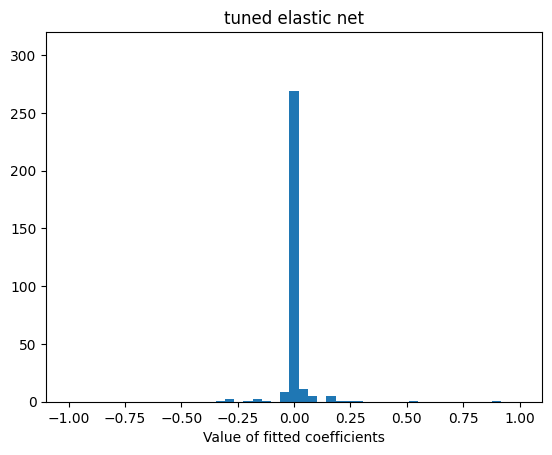

In [ ]:
n, bins, patches = plt.hist(x=best_enet_coef, bins=manual_bins)
plt.xlabel('Value of fitted coefficients')
plt.title('tuned elastic net')
plt.ylim((0,320))